In [1]:
import math
import time
import matplotlib.pyplot as plt
from gpiozero import LED
from gpiozero import Device
from gpiozero.pins.rpigpio import RPiGPIOFactory

from relay_controller import CapRelay
from serial_controller import SerialController

### Check device settings

In [2]:
import os, grp
print("User:", os.getlogin())
print("Groups:", [grp.getgrgid(g).gr_name for g in os.getgroups()])

User: picocontroller
Groups: ['adm', 'dialout', 'cdrom', 'sudo', 'audio', 'video', 'plugdev', 'games', 'users', 'netdev', 'gpio', 'i2c', 'spi', 'render', 'input', 'picocontroller']


# Setup

### Set up all GPIO

In [3]:
# RPi GPIO Pin Defs

RELAY_PINS = [22, 23, 24, 25]
TRIGGER_PIN = 17 # normally low. Triggers pico when set high

ALL_PINS = [22, 23, 24, 25, 17] # have to manually add all pins to this list

In [4]:
# Reset GPIO to safe state

# Replace the current pin factory (contains pin defs and reservations) with a fresh instance
Device.pin_factory = RPiGPIOFactory()

print("GPIO pin factory reset. All reservations cleared.")

# Explicitly set pins to safe states
for pin in ALL_PINS:
    led = LED(pin)
    led.off()
    led.close()
print("All utilized RPi GPIO pins reset.")

GPIO pin factory reset. All reservations cleared.
All utilized RPi GPIO pins reset.


### Set up relay controller

In [5]:
CHARGE_STATE = [1, 1, 1, 1]
NOT_DUMP_STATE = [0, 0, 1, 1]

relay = CapRelay(RELAY_PINS, CHARGE_STATE, NOT_DUMP_STATE)
relay.set_state("null") # should not change any pin assignments

All relays opened
RelayController initialized with 4 relays on pins [22, 23, 24, 25]
Relay 0 open (off)
Relay 1 open (off)
Relay 2 open (off)
Relay 3 open (off)
Switched to null state: [0, 0, 0, 0]
CapRelay initialized with 4 relays on pins [22, 23, 24, 25]
  Charge configuration: [1, 1, 1, 1]
  !Dump configuration: [0, 0, 1, 1]
Relay 0 open (off)
Relay 1 open (off)
Relay 2 open (off)
Relay 3 open (off)
Switched to null state: [0, 0, 0, 0]


In [6]:
# Relay test - DO NOT RUN WITH RELAY POWER
# TODO: write

### Set up Pico serial connection

In [19]:
# Create controller (adjust port as needed)
port = '/dev/ttyACM0'
controller = SerialController(port=port, debug=True)

# Start the background listener thread
# This starts a listener daemon which runs in the background until explicitly shut down. 
# Packets are placed in _response_queue and can be fetched with get_response()
controller.start_listener_thread()

print(f"Serial controller ready on {port}. Listener thread is running.")

Serial controller ready on /dev/ttyACM0. Listener thread is running.
[INFO]  init_serial(): Serial Connected!


# Operation Loop

### Compute Shot

In [8]:
maximum = 10000
pulseList = []

In [ ]:
# Simple sawtooth
nextNum = 100
flip = False


for i in range(0, maximum):
    pulseList.append(int(math.floor(nextNum)))

    if flip == False:
        nextNum += 0.05
    elif flip == True:
        nextNum -= 0.05
    
    if nextNum >= 200:
        flip = True
    elif nextNum <= 1:
        flip = False

print(f"Pulse list of length {maximum} computed. Displaying...")

plt.plot(pulseList)

0.01
Pulse list of length 10000 computed. Displaying...


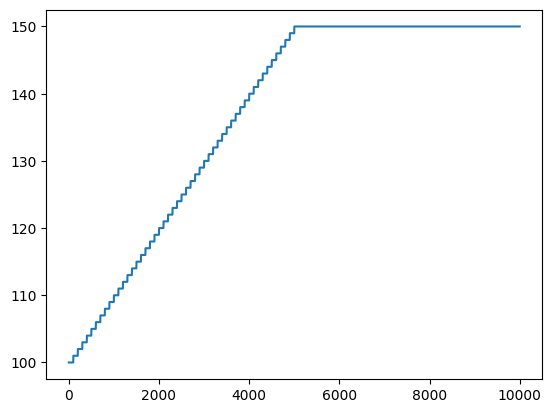

In [9]:
# Rampup to flattop

# Ramp up for the first half of operation
ramp_length = int(math.floor(maximum/2))

zero = 100
target = 150
inc = (target-zero)/ramp_length

print(inc)

num = zero
for i in range(0, ramp_length):
    pulseList.append(int(math.floor(num)))
    num += inc

# Flattop for the second half
for i in range(ramp_length + 1, maximum):
    pulseList.append(target)

print(f"Pulse list of length {maximum} computed. Displaying...")

plt.plot(pulseList)

### Charge Capatitor Bank
Placed before loading pico for now. make sure that's the right order later.

CAUTION: Following this point, the system is armed.

In [20]:
print("Preparing to charge capacitor bank...")

usr_arm = input("Arm system? (y/n)") # do this better

if usr_arm == "y":
    time.sleep(1)
    print("Charging capacitor bank...")
    time.sleep(1)
    relay.set_state("charge")

Preparing to charge capacitor bank...
Charging capacitor bank...
Relay 0 closed (on)
Relay 1 closed (on)
Relay 2 closed (on)
Relay 3 closed (on)
Switched to charge state: [1, 1, 1, 1]


In [ ]:
# Dump capacitors (do not run this cell during operation. Here to prevent Run All from working)
relay.set_state("null")

### Load shot data to pico

In [21]:
controller.send_pwm_pulses(pulseList)
print(f"Sent {len(pulseList)} PWM pulses to pico at {port}.")

# TODO: add verification of ack once that is implemented in pico firmware

print("Pico is now waiting for trigger to fire.")

Sent 9999 PWM pulses
Sent 9999 PWM pulses to pico at /dev/ttyACM0.
Pico is now waiting for trigger to fire.


[INFO]  serial_input(): Complete packet of length 9999 received.
[INFO]  wait_for_pin_high(): Awaiting trigger (debounce = 1000 us).


### Fire trigger!

In [22]:
trigger = LED(TRIGGER_PIN)

# Disconnect power supply 10ms before firing
relay.set_state("!dump")
time.sleep(0.01)

# Pulse trigger
trigger.on()
time.sleep(0.5) # full shot lasts 500ms
trigger.off()

trigger.close()

# Return relays to default dump state
relay.set_state("null")

Relay 0 open (off)
Relay 1 open (off)
Relay 2 closed (on)
Relay 3 closed (on)
Switched to !dump state: [0, 0, 1, 1]
[INFO]  wait_for_pin_high(): Triggered.
Relay 0 open (off)
Relay 1 open (off)
Relay 2 open (off)
Relay 3 open (off)
Switched to null state: [0, 0, 0, 0]


[INFO]  build_packet(): Building return packet of packet_length= 10005 and msg_type= 0x80
[INFO]  build_packet(): Data copied successfully
[INFO]  serial_output(): packet built
[INFO]  serial_output(): Writing return packet
[INFO]  serial_output(): packet[0]=aa, packet_length=10005
[INFO]  build_packet(): Building return packet of packet_length= 10005 and msg_type= 0x82
[INFO]  build_packet(): Data copied successfully
[INFO]  serial_output(): packet built
[INFO]  serial_output(): Writing return packet
[INFO]  serial_output(): packet[0]=aa, packet_length=10005
[INFO]  build_packet(): Building return packet of packet_length= 10005 and msg_type= 0x81
[INFO]  build_packet(): Data copied successfully
[INFO]  serial_output(): packet built
[INFO]  serial_output(): Writing return packet
[INFO]  serial_output(): packet[0]=aa, packet_length=10005


### Retrieve Response

In [ ]:
# in progress
response = controller.get_response(timeout=2.0)

if response:
    msg_type, data = response
    print(f"Received response: Type={msg_type}, Data length={len(data)}")
    print(f"Data values: {data[:10]}...")  # show first 10 values

else:
    print("No response received within timeout. Check device connectivity or trigger.")

### Reset

In [18]:
# Run this cell when you are done or need to re-initialise.
controller.stop_listener_thread()
controller.close()
print("Serial connection closed and listener stopped.")

# To fully reset, restart the kernel and power cycle the pico (only for now)

Serial connection closed and listener stopped.
